## Authors & Contributors

This work was developed by:
* **Patricia Mares-Nasarre** – Delft University of Technology ([P.MaresNasarre@tudelft.nl](mailto:P.MaresNasarre@tudelft.nl))
* **Pierre Karamountzos** – Imperial College London ([pierre.karamountzos25@imperial.ac.uk](mailto:pierre.karamountzos25@imperial.ac.uk))

---

# Non-Parametric Bayesian Network (NPBN) for PyPSA-KE Sensitivity Analysis

This notebook provides an end-to-end workflow structured into three key stages:
1. **Building the NPBN**: Loading dataset, unit transformation ($MWh \to GWh$), DAG specification, and rank correlation fitting.
2. **Validation & Diagnostics**: $d$-calibration testing, train/test split evaluation, empirical coverage rate (ECR) assessment, and QQ-plot analysis ($R^2$).
3. **Scenario Inference**: Conditioning the network via sample-based conditioning on exogenous energy system parameters (Demand percentile ranges vs. median cost and tax bounds) and deriving posterior distributions for Pumped Hydro Storage (PHS) capacity.

## 0. Dependencies and Setup

In [1]:
import os
import re
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

from py_banshee.rankcorr import bn_rankcorr
from py_banshee.bn_plot import bn_visualize
from py_banshee.d_cal import test_distance, gaussian_distance
from py_banshee.copula_test import cvm_statistic
from py_banshee.prediction import inference, conditional_margins_hist
from py_banshee.sample_bn import sample_based_conditioning, generate_samples

## 1. Building the NPBN
### 1.1 Data Ingestion, Cleaning, and Unit Transformation

In [2]:
# Update path as required for your local environment
file_name = "PyPSA-KE_MC_samples.csv"

data = pd.read_csv(file_name)

# Drop index/irrelevant columns if present
drop_cols = ['PHS_Store_MWh_PHS_Lake Turkana_store', 'Run ID']
data.drop(columns=[col for col in drop_cols if col in data.columns], inplace=True)

# Reorder columns so that exogenous parent parameters come first
desired_order = ["Demand coefficient", "Battery cost coefficient", "Solar CAPEX coefficient", "CO2 tax coefficient"]
other_cols = [col for col in data.columns if col not in desired_order]
data = data[desired_order + other_cols]

# Convert PHS capacities from MWh to GWh
for col in data.columns:
    if 'MWh' in col:
        data[col] = data[col] / 1000.0

# LaTeX Symbol Mapping for downstream plotting
name_map = {
    # PHS Sites (Energy capacity symbols standardized to E with local subscripts)
    "PHS_Store_MWh_PHS_Lake Logipi_store": r"$E_{\mathrm{L}}$",
    "PHS_Store_MWh_PHS_Lake Solai_store": r"$E_{\mathrm{So}}$",
    "PHS_Store_MWh_PHS_Olbollosat_store": r"$E_{\mathrm{O}}$",
    "PHS_Store_MWh_PHS_Lake Magadi_store": r"$E_{\mathrm{M}}$",
    "PHS_Store_MWh_PHS_Krinyaga_store": r"$E_{\mathrm{K}}$",
    "PHS_Store_MWh_PHS_Lake Victoria_store": r"$E_{\mathrm{V}}$",
    "PHS_Store_MWh_PHS_Seven Forks_store": r"$E_{\mathrm{SF}}$",
    
    # Exogenous Parameters (using clean multipliers / coefficients)
    "Demand coefficient": r"$\tau_{\mathrm{dem}}$",
    "CO2 tax coefficient": r"$\tau_{\mathrm{CO_2}}$",
    "Battery cost coefficient": r"$\tau_{\mathrm{bat}}$",
    "Solar CAPEX coefficient": r"$\tau_{\mathrm{sol}}$",
}

display(data.describe())

,Demand coefficient,Battery cost coefficient,Solar CAPEX coefficient,CO2 tax coefficient,PHS_Store_MWh_PHS_Lake Logipi_store,PHS_Store_MWh_PHS_Lake Solai_store,PHS_Store_MWh_PHS_Olbollosat_store,PHS_Store_MWh_PHS_Lake Magadi_store,PHS_Store_MWh_PHS_Krinyaga_store,PHS_Store_MWh_PHS_Lake Victoria_store,PHS_Store_MWh_PHS_Seven Forks_store
count,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000
mean,0.809477,1.120355,1.015369,2.000166,6.480132,6.265743,3.844950,14.364631,10.571678,6.384283,11.123947
std,0.306668,0.243188,0.349902,1.159202,3.648942,7.956283,3.317300,6.421797,3.653750,4.925205,10.015545
min,0.280000,0.700000,0.410000,0.000000,1.156688,0.237907,0.000087,1.427527,0.001286,0.000022,0.000044
25%,0.544761,0.910810,0.713166,1.001442,3.732716,0.859790,0.232390,8.540993,7.777764,1.952948,0.002255
50%,0.809267,1.119668,1.016371,1.997816,5.477658,1.824677,3.683019,13.995882,12.080179,6.402112,9.492150
75%,1.074755,1.330947,1.316936,3.001267,8.390107,9.444149,6.300974,18.933544,13.763173,9.003667,21.897338
max,1.340000,1.540000,1.620000,4.000000,15.752403,30.075924,13.405288,28.994561,13.763176,20.533880,25.002011


### 1.2 Pairwise Copula Scatter Matrix (Unity Space)

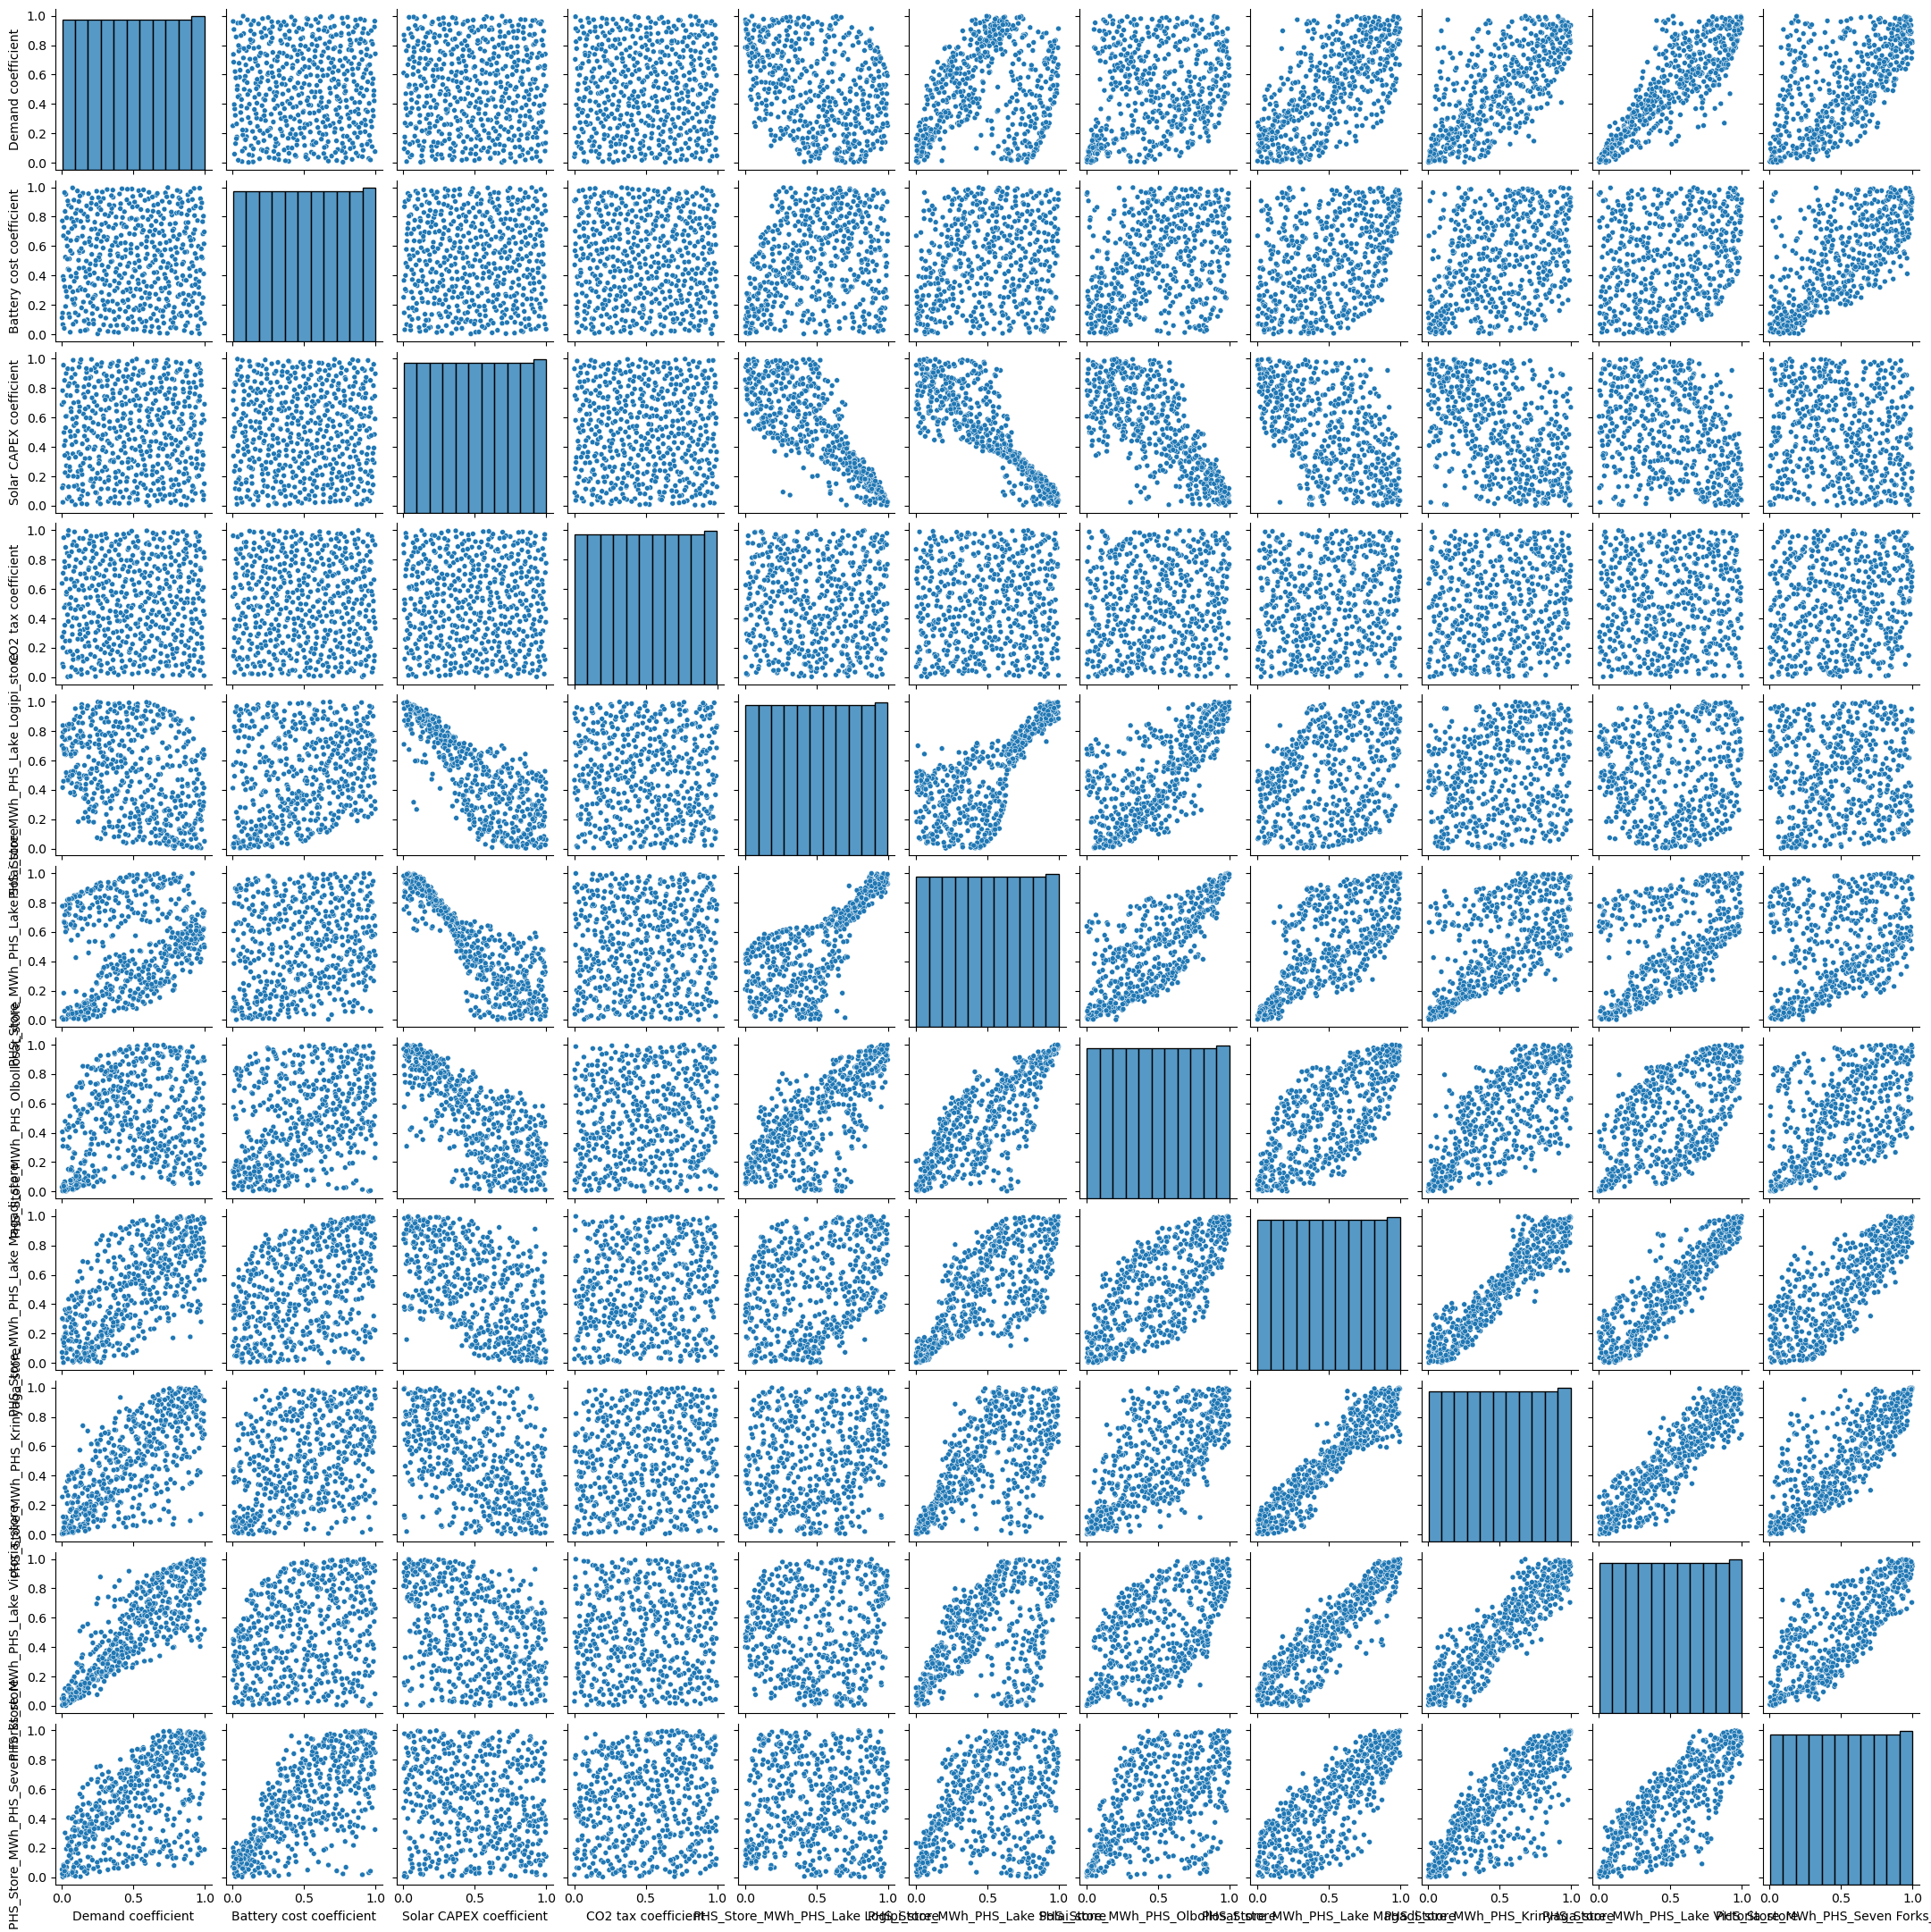

In [3]:
def unity(data):
    M = data.shape[0]  # Reading number of observations per node
    ranks = data.rank(axis=0)
    u_hat = ranks / (M + 1)
    return u_hat

unity_data = unity(data)
sns.pairplot(unity_data, height=2,plot_kws=dict(size=.1))

# def sd_normal(data):
#     M = data.shape[0]  # Reading number of observations per node
#     ranks = data.rank(axis=0)
#     u_hat = ranks / (M + 1)
#     sd_data = stats.norm.ppf(u_hat)
#     return sd_data

# sd_data = pd.DataFrame(sd_normal(data), columns = data.columns)
# sns.pairplot(sd_data, height=1,plot_kws=dict(size=.1))

Gaussian copula has the lowest CvM for 25.5% of variable pairs.
Symmetric copulas (Gaussian & Frank) have the lowest CvM for 60.0% of variable pairs.


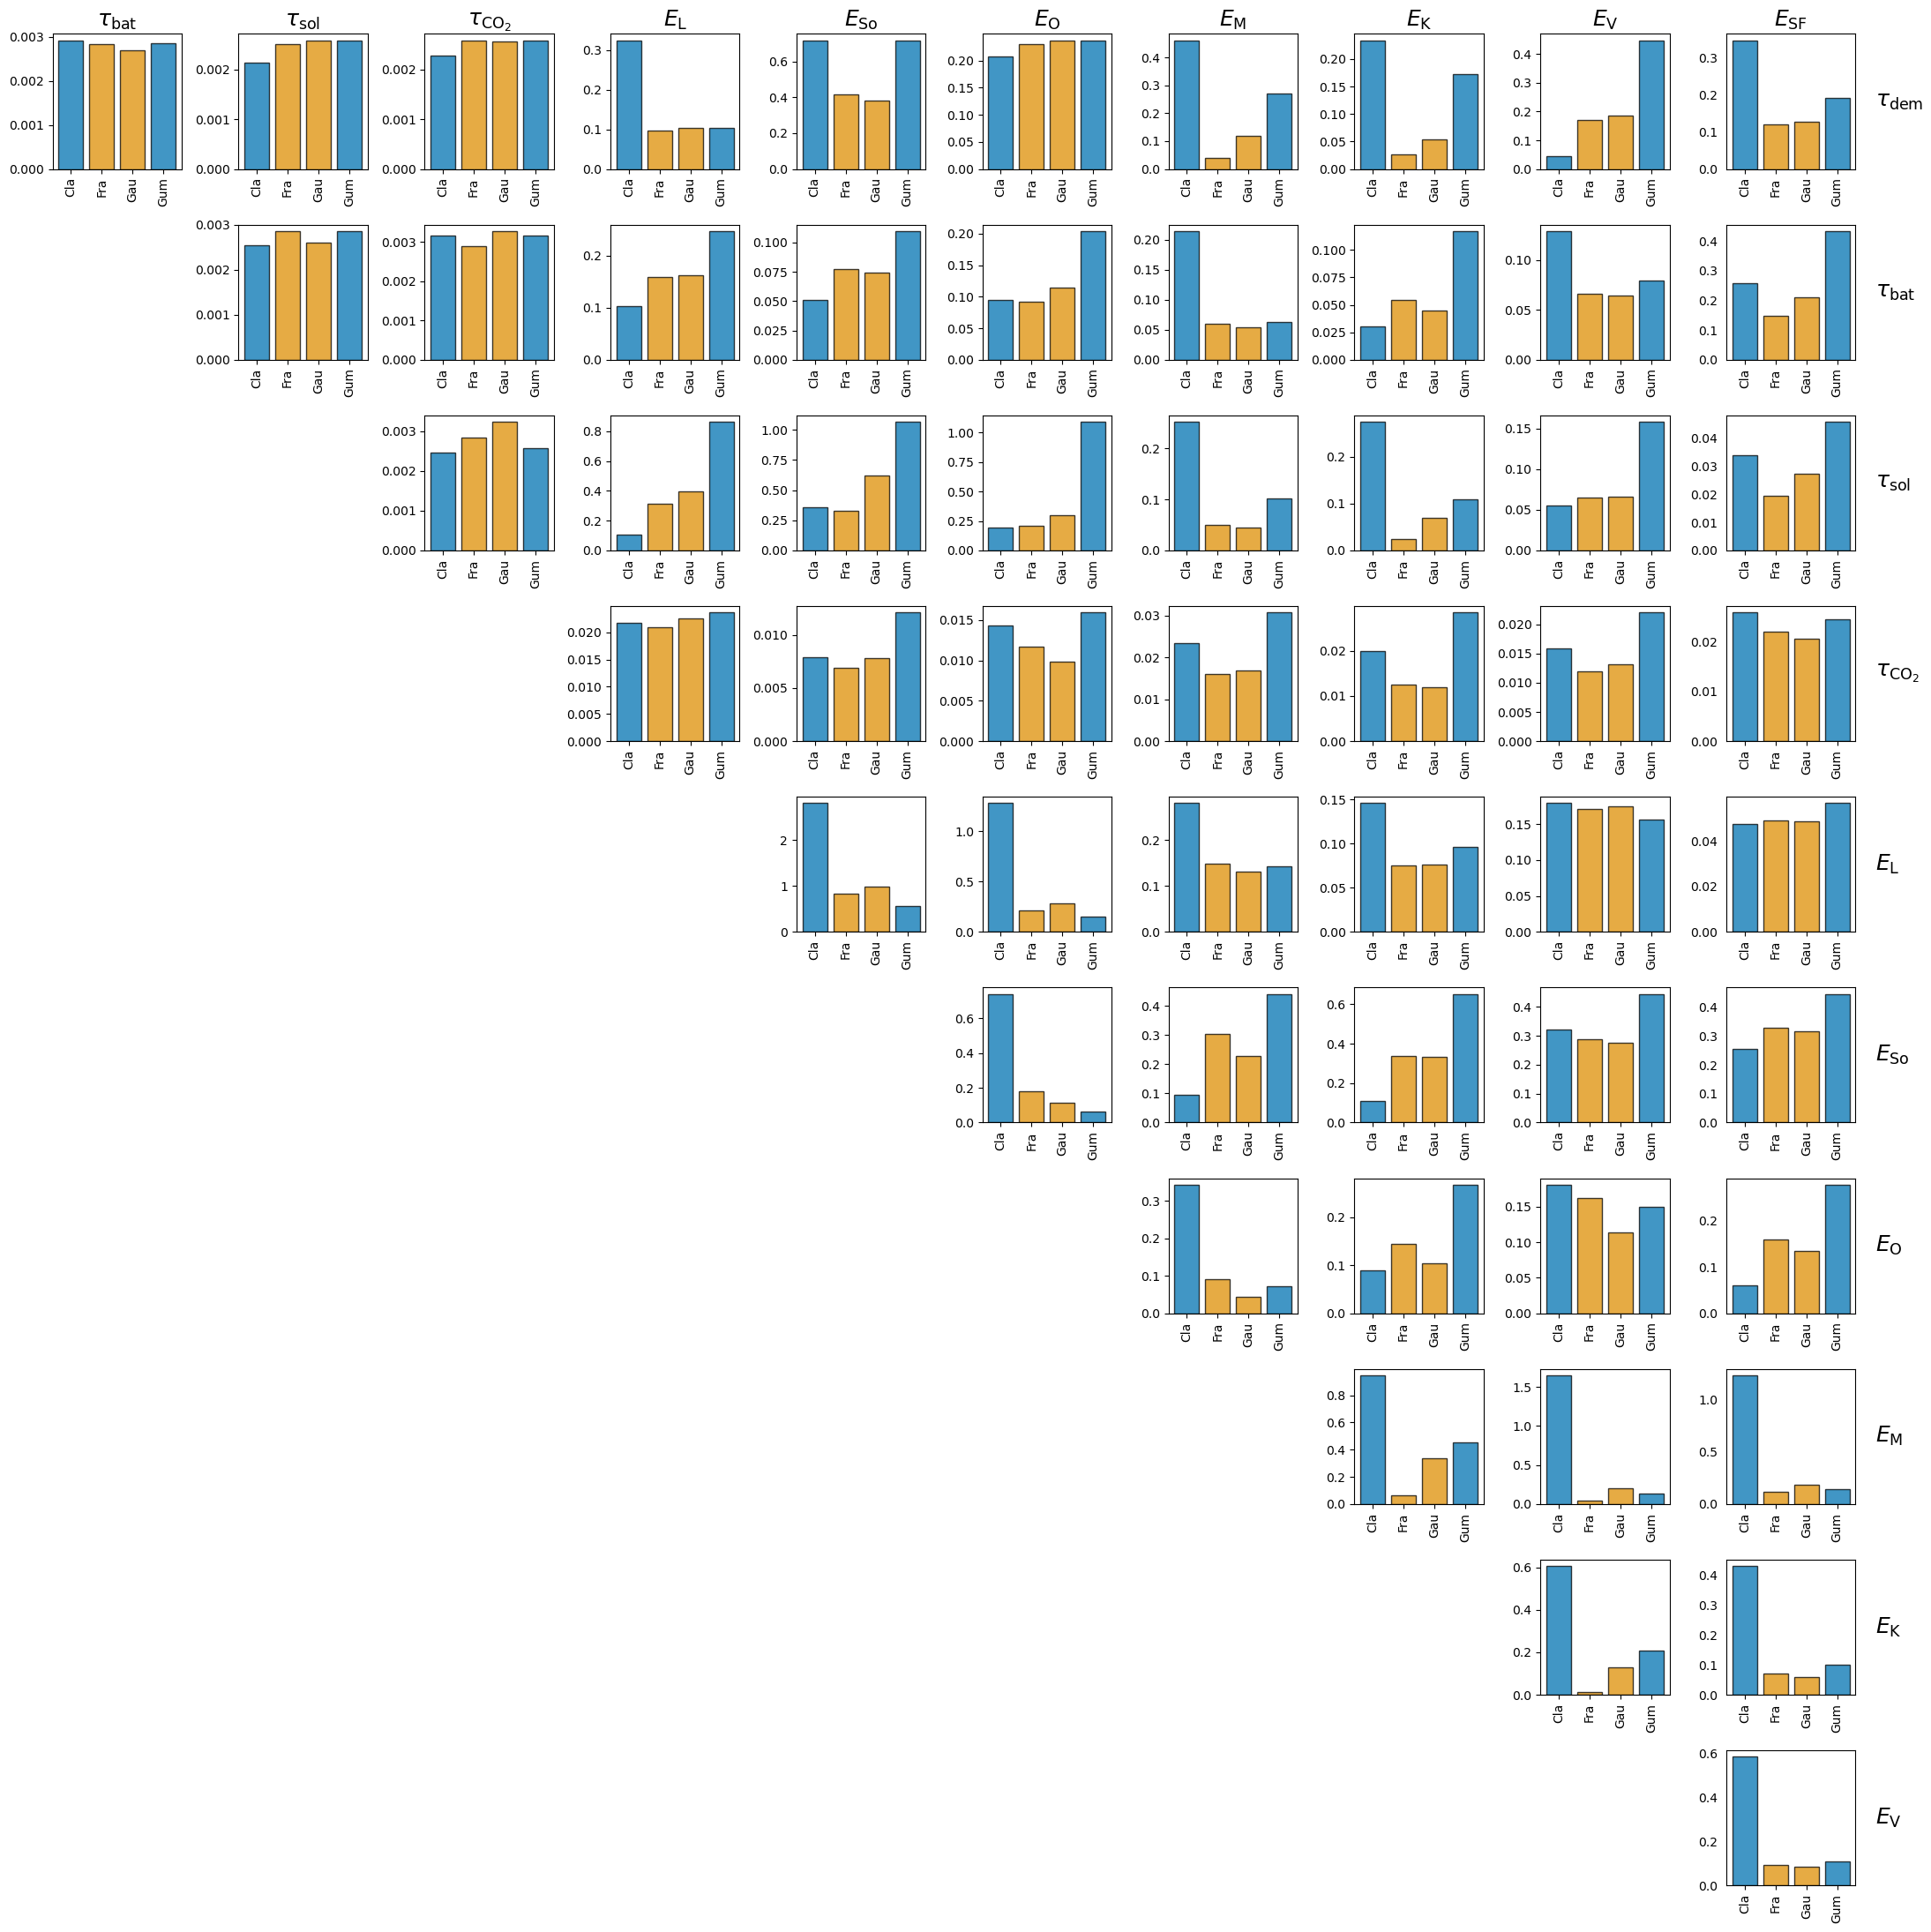

In [4]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(data, plot=1, names=data.columns,folder = None, fig_name='CvM',name_map=name_map)

In [5]:
#Transform data to standard normal and store it in a DataFrame\
standard_data = pd.DataFrame(data=stats.norm.ppf(unity_data), columns=unity_data.columns)

#Compute pearson correlation matrix
rho_N = np.corrcoef(standard_data, rowvar=False)

#Transform to rank correlation matrix
R_N = (6 / np.pi) * np.arcsin(rho_N / 2)

### 1.3 Specifying the DAG Structure and Fitting the Full NPBN

In [6]:
names = list(data.columns)
N = data.shape[1]

# Define parent-child structure based on physical & statistical dependencies
parents1 = [None] * N
parents1[0] = []            # Demand coefficient
parents1[1] = []            # Battery cost coefficient
parents1[2] = []            # Solar CAPEX coefficient
parents1[3] = []            # CO2 tax coefficient
parents1[4] = [0, 1, 2, 8]  # Logipi
parents1[5] = [2, 6]        # Solai
parents1[6] = [2, 3, 4, 9]  # Olbollosat
parents1[7] = [0, 1, 2, 3]  # Lake Magadi
parents1[8] = [0, 1, 2, 3, 7] # Krinyaga
parents1[9] = [0, 2, 10]    # Lake Victoria
parents1[10] = [0, 1, 3, 8] # Seven Forks

# Fit the full model
folder_name = 'final_NPBN'
R_BN_full = bn_rankcorr(parents1, data, folder=folder_name, var_names=names, is_data=True, plot=False)

## 2. Validation & Diagnostic Testing
### 2.0 Rank correlation matrices

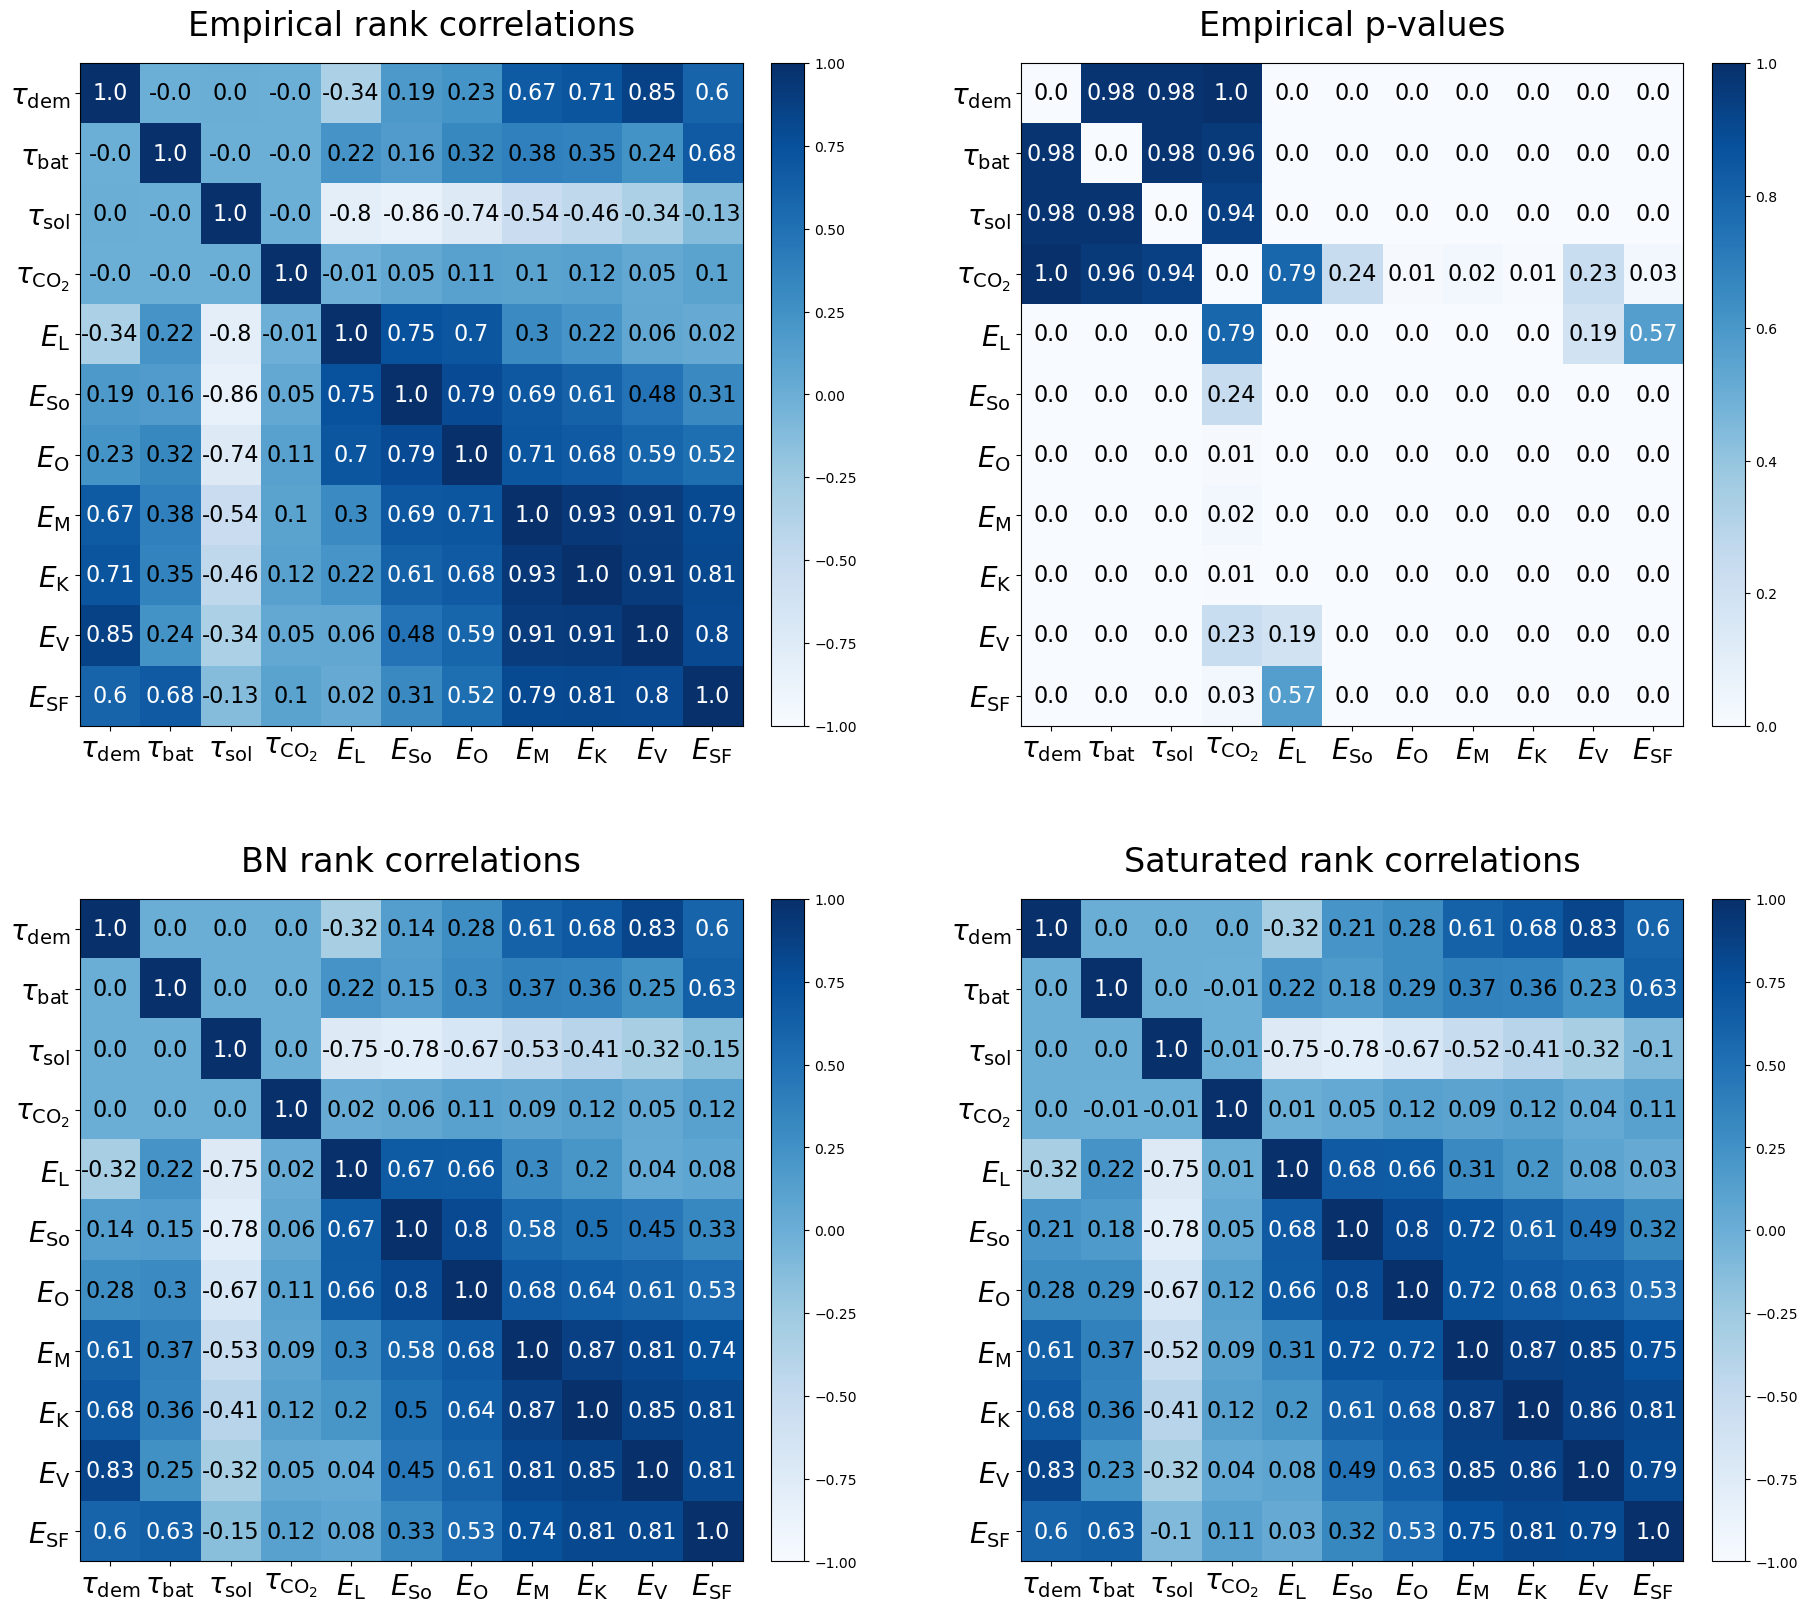

In [7]:
# Calculate the rank correlation matrix
R_e, p_values = stats.spearmanr(data)

# Generate symbols list matching the order of your columns
nam = list(data.columns)
# Extract the LaTeX symbol if name_map values are tuples (symbol, unit)
nam_symb = [name_map[c][0] if isinstance(name_map.get(c), tuple) else name_map.get(c, c) for c in nam]
px = list(range(len(nam)))

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(18, 16), layout="constrained")
fig.set_constrained_layout_pads(wspace=0.1, hspace=0.1)  # spacing between panels

# Row 1, Col 0: Empirical rank correlations
im1 = axes[0, 0].imshow(R_e, cmap="Blues", vmin=-1, vmax=1)
axes[0, 0].set_xticks(px, nam_symb, rotation=0, fontsize=20)
axes[0, 0].set_yticks(px, nam_symb, fontsize=20)
axes[0, 0].set_title("Empirical rank correlations", fontsize=24, pad=20)

zz2 = np.round(R_e, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        color = "w" if zz2[i, j] > 0.5 else "k"
        axes[0, 0].text(j, i, zz[i, j], ha="center", va="center", fontsize=16, color=color)
cbar = fig.colorbar(im1, ax=axes[0, 0], fraction=0.05, pad=0.04)

# Row 1, Col 1: Empirical p-values
im2 = axes[0, 1].imshow(p_values, cmap="Blues", vmin=0, vmax=1)
axes[0, 1].set_xticks(px, nam_symb, rotation=0, fontsize=20)
axes[0, 1].set_yticks(px, nam_symb, fontsize=20)
axes[0, 1].set_title("Empirical p-values", fontsize=24, pad=20)

zz2 = np.round(p_values, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        color = "w" if zz2[i, j] > 0.5 else "k"
        axes[0, 1].text(j, i, zz[i, j], ha="center", va="center", fontsize=16, color=color)
cbar = fig.colorbar(im2, ax=axes[0, 1], fraction=0.05, pad=0.04)

# Row 2, Col 0: BN rank correlations
im3 = axes[1, 0].imshow(R_BN_full, cmap="Blues", vmin=-1, vmax=1)
axes[1, 0].set_xticks(px, nam_symb, rotation=0, fontsize=20)
axes[1, 0].set_yticks(px, nam_symb, fontsize=20)
axes[1, 0].set_title("BN rank correlations", fontsize=24, pad=20)

zz2 = np.round(R_BN_full, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        color = "w" if zz2[i, j] > 0.5 else "k"
        axes[1, 0].text(j, i, zz[i, j], ha="center", va="center", fontsize=16, color=color)
cbar = fig.colorbar(im3, ax=axes[1, 0], fraction=0.05, pad=0.04)

# Row 2, Col 1: Saturated rank correlations
im4 = axes[1, 1].imshow(R_N, cmap="Blues", vmin=-1, vmax=1)
axes[1, 1].set_xticks(px, nam_symb, rotation=0, fontsize=20)
axes[1, 1].set_yticks(px, nam_symb, fontsize=20)
axes[1, 1].set_title("Saturated rank correlations", fontsize=24, pad=20)

zz2 = np.round(R_N, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        color = "w" if zz2[i, j] > 0.5 else "k"
        axes[1, 1].text(j, i, zz[i, j], ha="center", va="center", fontsize=16, color=color)
cbar = fig.colorbar(im4, ax=axes[1, 1], fraction=0.05, pad=0.04)

plt.show()

### 2.1 $d$-Calibration Robustness Test

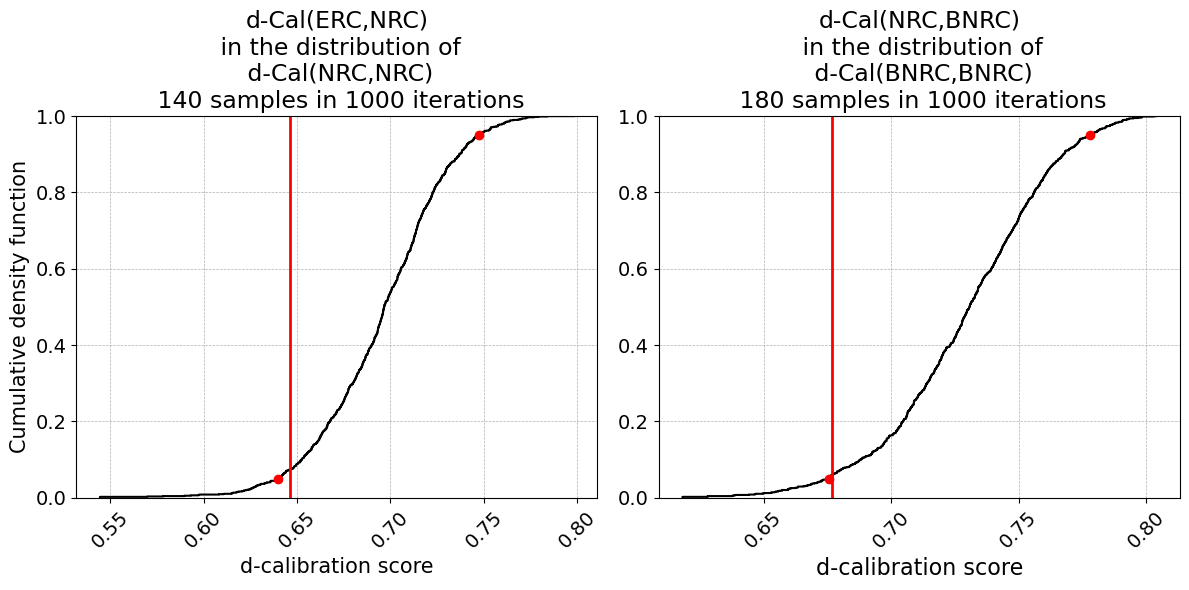

SUCCESS: The d-Cal of the empirical rank correlation matrix (ERC) fall between the confidence intervals of the d-Cal of the normal rank correlation matrix (NRC)

SUCCESS: The d-Cal of the normal rank correlation matrix (NRC) fall between the confidence intervals of the d-Cal of the BN rank correlation matrix (BNRC)



(array(0.6461856),
 array([0.63982713, 0.74748751]),
 array(0.67673387),
 array([0.67548283, 0.77805119]))

In [8]:
# Statistical validation against Gaussian copula assumption
gaussian_distance(R_BN_full, data, 140, 180, 1000, Plot=True)

### 2.2 Cross-Validation: Train/Test Split and Inference Pipeline

In [15]:
# Split into training (80%) and testing (20%) sets
train_df, test_df = train_test_split(data, test_size=0.2, random_state=9)

# Fit NPBN specifically on the training partition
R_BN_train = bn_rankcorr(parents1, train_df, folder=folder_name, var_names=names, is_data=True, plot=False)

def run_bn_inference(eval_df, empirical_df, R_BN, n_nodes=7, n_draws=300, parent_indices=[0, 1, 2, 3]):
    """
    Executes conditional inference over evaluation samples using empirical inverse CDFs from empirical_df.
    """
    condition_values = eval_df.iloc[:, parent_indices].to_numpy()
    n_samples = len(condition_values)
    stats_all = np.zeros((n_samples, n_nodes, 4))  # 0: true, 1: median, 2: 5th pct, 3: 95th pct

    for i in range(n_samples):
        row_values = condition_values[i:i+1, :]
        F = inference(
            Nodes=parent_indices,
            Values=row_values,
            R=R_BN,
            DATA=empirical_df,
            Output='full',
            SampleSize=n_draws,
            Interp='next',
            empirical_data=True,
            distributions=[],
            parameters=[]
        )
        sample_draws = np.squeeze(F)
        true_values = eval_df.iloc[i, len(parent_indices):len(parent_indices) + n_nodes].to_numpy()

        stats_all[i, :, 0] = true_values
        stats_all[i, :, 1] = np.median(sample_draws, axis=1)
        stats_all[i, :, 2] = np.percentile(sample_draws, 5, axis=1)
        stats_all[i, :, 3] = np.percentile(sample_draws, 95, axis=1)

    inside_perc = ((stats_all[:, :, 0] >= stats_all[:, :, 2]) & 
                   (stats_all[:, :, 0] <= stats_all[:, :, 3])).mean(axis=0) * 100.0

    print(f"Inference complete for {n_samples} samples. Coverage computed.")
    return condition_values, stats_all, inside_perc

def plot_node_performance(stats_all, node_names, subset="train", output_dir="CI_plots_90", name_map=None):
    """
    Plots Empirical Coverage Rate (ECR) bands (90% CI) vs PyPSA-KE ground truth.
    """
    # os.makedirs(output_dir, exist_ok=True)
    n_samples, n_nodes, _ = stats_all.shape
    palette = sns.color_palette("colorblind")

    for j, raw_name in enumerate(node_names):
        symbol, unit = name_map.get(raw_name, (raw_name, ""))
        y_true = stats_all[:, j, 0]
        y_med  = stats_all[:, j, 1]
        y_low  = stats_all[:, j, 2]
        y_high = stats_all[:, j, 3]
        inside = ((y_true >= y_low) & (y_true <= y_high)).mean() * 100.0

        x = np.arange(n_samples)
        plt.figure(figsize=(10, 5))
        n_plot_0, n_plot = 20, min(70, n_samples)

        plt.plot(x[n_plot_0:n_plot], y_true[n_plot_0:n_plot], "s", lw=1, label="PyPSA-KE")
        plt.plot(x[n_plot_0:n_plot], y_med[n_plot_0:n_plot], "s", color=palette[1], alpha=0.75, label="BN median")
        plt.fill_between(x[n_plot_0:n_plot], y_low[n_plot_0:n_plot], y_high[n_plot_0:n_plot],
                         color=palette[0], alpha=0.3, hatch="//", label="BN 90% interval")

        plt.xlabel("Sample index", fontsize=14)
        plt.ylabel(f"{symbol} {unit}", fontsize=14)
        plt.title(f"{symbol} - ECR ({subset}) = {inside:.2f}%", fontsize=16)
        plt.legend(loc='upper left', fontsize=12)
        plt.grid(axis="y")
        plt.tight_layout()

        safe_name = re.sub(r"[^\w]+", "_", raw_name)
        # filepath = os.path.join(output_dir, f"{safe_name}_{subset}.png")
        # plt.savefig(filepath, dpi=300)
        plt.close()

def qqplot_node_performance(stats_all, node_names, subset="train", output_dir="QQ_plots", name_map=None):
    """
    Generates quantile-quantile plots and outputs R^2 scores between BN medians and PyPSA-KE values.
    """
    # os.makedirs(output_dir, exist_ok=True)
    n_samples, n_nodes, _ = stats_all.shape
    palette = sns.color_palette("colorblind")

    r2_scores = []
    for j, raw_name in enumerate(node_names):
        symbol, unit = name_map.get(raw_name, (raw_name, ""))
        y_true = stats_all[:, j, 0]
        y_pred = stats_all[:, j, 1]
        r2 = r2_score(y_true, y_pred)
        r2_scores.append(r2)

        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=0.75, marker=".", color=palette[1], label="BN median vs PyPSA-KE", s=60)
        min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.2, label="y = x", alpha=0.75)

        plt.xlim(min_val, max_val)
        plt.ylim(min_val, max_val)
        plt.xlabel(f"{symbol} {unit} (PyPSA-KE)", fontsize=14)
        plt.ylabel(f"{symbol} {unit} (BN)", fontsize=14)
        plt.title(f"{symbol} ({subset}) | $R^2$ = {r2:.2f}", fontsize=16)
        plt.legend(fontsize=12, loc="lower right")
        plt.grid()
        plt.tight_layout()

        safe_name = re.sub(r"[^\w]+", "_", raw_name)
        # filepath = os.path.join(output_dir, f"QQ_{safe_name}_{subset}.png")
        # plt.savefig(filepath, dpi=300)
        plt.close()

    return pd.DataFrame({f"R2_{subset}": r2_scores, "Raw_name": node_names})

### 2.3 Running Cross-Validation and Computing Metric Summary

In [16]:
# Execute inference on train and test partitions
cond_train, stats_train, inside_train = run_bn_inference(train_df, train_df, R_BN_train)
cond_test, stats_test, inside_test = run_bn_inference(test_df, train_df, R_BN_train)

node_names = list(train_df.columns[4:])

# Create ECR Dataframe
inside_df = pd.DataFrame({
    "Raw_name": node_names,
    "Inside_CI_train (%)": inside_train,
    "Inside_CI_test (%)": inside_test
})

name_map_val = {
    "PHS_Store_MWh_PHS_Lake Logipi_store": (r"$E_{\mathrm{L}}$", "[GWh]"),
    "PHS_Store_MWh_PHS_Lake Solai_store": (r"$E_{\mathrm{So}}$", "[GWh]"),
    "PHS_Store_MWh_PHS_Olbollosat_store": (r"$E_{\mathrm{O}}$", "[GWh]"),
    "PHS_Store_MWh_PHS_Lake Magadi_store": (r"$E_{\mathrm{M}}$", "[GWh]"),
    "PHS_Store_MWh_PHS_Krinyaga_store": (r"$E_{\mathrm{K}}$", "[GWh]"),
    "PHS_Store_MWh_PHS_Lake Victoria_store": (r"$E_{\mathrm{V}}$", "[GWh]"),
    "PHS_Store_MWh_PHS_Seven Forks_store": (r"$E_{\mathrm{SF}}$", "[GWh]")
}

# Generate CI plots
plot_node_performance(stats_train, node_names, subset="train", output_dir="CI_plots_90", name_map=name_map_val)
plot_node_performance(stats_test, node_names, subset="test", output_dir="CI_plots_90", name_map=name_map_val)

# Generate QQ plots & R2 tables
r2_train_df = qqplot_node_performance(stats_train, node_names, subset="train", output_dir="QQ_plots", name_map=name_map_val)
r2_test_df  = qqplot_node_performance(stats_test, node_names, subset="test", output_dir="QQ_plots", name_map=name_map_val)
r2_all = pd.merge(r2_train_df, r2_test_df, on="Raw_name")

# Output full performance table
performance_df = inside_df.merge(r2_all, on="Raw_name").round(2)
display(performance_df)

Inference complete for 423 samples. Coverage computed.
Inference complete for 106 samples. Coverage computed.


,Raw_name,Inside_CI_train (%),Inside_CI_test (%),R2_train,R2_test
0,PHS_Store_MWh_PHS_Lake Logipi_store,90.31,81.13,0.76,0.66
1,PHS_Store_MWh_PHS_Lake Solai_store,91.73,86.79,0.73,0.67
2,PHS_Store_MWh_PHS_Olbollosat_store,90.54,94.34,0.68,0.65
3,PHS_Store_MWh_PHS_Lake Magadi_store,90.54,83.02,0.88,0.83
4,PHS_Store_MWh_PHS_Krinyaga_store,91.73,92.45,0.87,0.81
5,PHS_Store_MWh_PHS_Lake Victoria_store,90.54,89.62,0.88,0.86
6,PHS_Store_MWh_PHS_Seven Forks_store,91.25,88.68,0.84,0.79


## 3. Inferring Scenarios
### 3.1 Defining and Evaluating Exogenous Stress Scenarios
- **Scenario P1**: Low demand ($0-25\text{th}$ percentile) with median cost and tax bounds ($40-60\text{th}$ percentiles).
- **Scenario P2**: High demand ($75-100\text{th}$ percentile) with median cost and tax bounds ($40-60\text{th}$ percentiles).

In [17]:
# --- Configuration & Setup ---
condition_nodes = {
    r"Scenario P1": [0, 1, 2, 3],
    r"Scenario P2": [0, 1, 2, 3],
}

# Parameter 0 uses interval bounds for demand; parameters 1, 2, and 3 use median interval bounds
scenarios = {
    r"Scenario P1": [(0.0, 0.25), (0.40, 0.60), (0.40, 0.60), (0.40, 0.60)],
    r"Scenario P2": [(0.75, 1.0), (0.40, 0.60), (0.40, 0.60), (0.40, 0.60)]
}

# 1. Identify variables used for conditioning in ANY scenario
all_conditioned_indices = set()
for nodes in condition_nodes.values():
    if isinstance(nodes, int): 
        all_conditioned_indices.add(nodes)
    else:
        all_conditioned_indices.update(nodes)

# 2. Identify common inferred variables
total_vars = data.shape[1]
plot_indices = [i for i in range(total_vars) if i not in all_conditioned_indices]
if len(plot_indices) > 7:
    plot_indices = plot_indices[-7:]

scenario_params = {}
scenario_results = {}
val_stored_global = {}

for label, mix_targets in scenarios.items():
    print(f"Processing: {label}")
    current_nodes = condition_nodes[label]
    if isinstance(current_nodes, int):
        current_nodes = [current_nodes]
    
    # Dynamically resolve values: compute tuples for ranges, floats for scalars
    condition_values = []
    for idx, i in enumerate(current_nodes):
        target = mix_targets[idx]
        if isinstance(target, tuple):
            low_val = data.iloc[:, i].quantile(target[0])
            high_val = data.iloc[:, i].quantile(target[1])
            condition_values.append((low_val, high_val))
        else:
            condition_values.append(data.iloc[:, i].quantile(target))
            
    scenario_params[label] = condition_values
    
    # 1. Generate unconditional baseline samples using generate_samples
    unconditional_samples = generate_samples(
        R=R_BN_full,
        n=6000000,                      # Number of samples requested
        names=list(data.columns),       # Names of the nodes
        data=data,                      # Empirical database
        empirical_data=True
    )
    
    # 2. Condition the generated samples on scenario Node intervals
    conditioned_df = sample_based_conditioning(
        data=unconditional_samples,
        condition_nodes=current_nodes,
        LowerBound_UpperBound=condition_values
    )

    print(f"Scenario {label}: {len(conditioned_df)} samples after conditioning.")
    
    # Convert to transposed numpy array format for plotting
    samples_gen_transposed = conditioned_df.to_numpy().T
    
    mapping = {i: i for i in range(total_vars)}
    scenario_results[label] = {
        "data": [samples_gen_transposed],
        "mapping": mapping
    }

    val_stored_global[label] = None

Processing: Scenario P1
Scenario Scenario P1: 11934 samples after conditioning.
Processing: Scenario P2
Scenario Scenario P2: 11702 samples after conditioning.


### 3.2 Visualizing Inferred Posterior Capacity Distributions across Scenarios

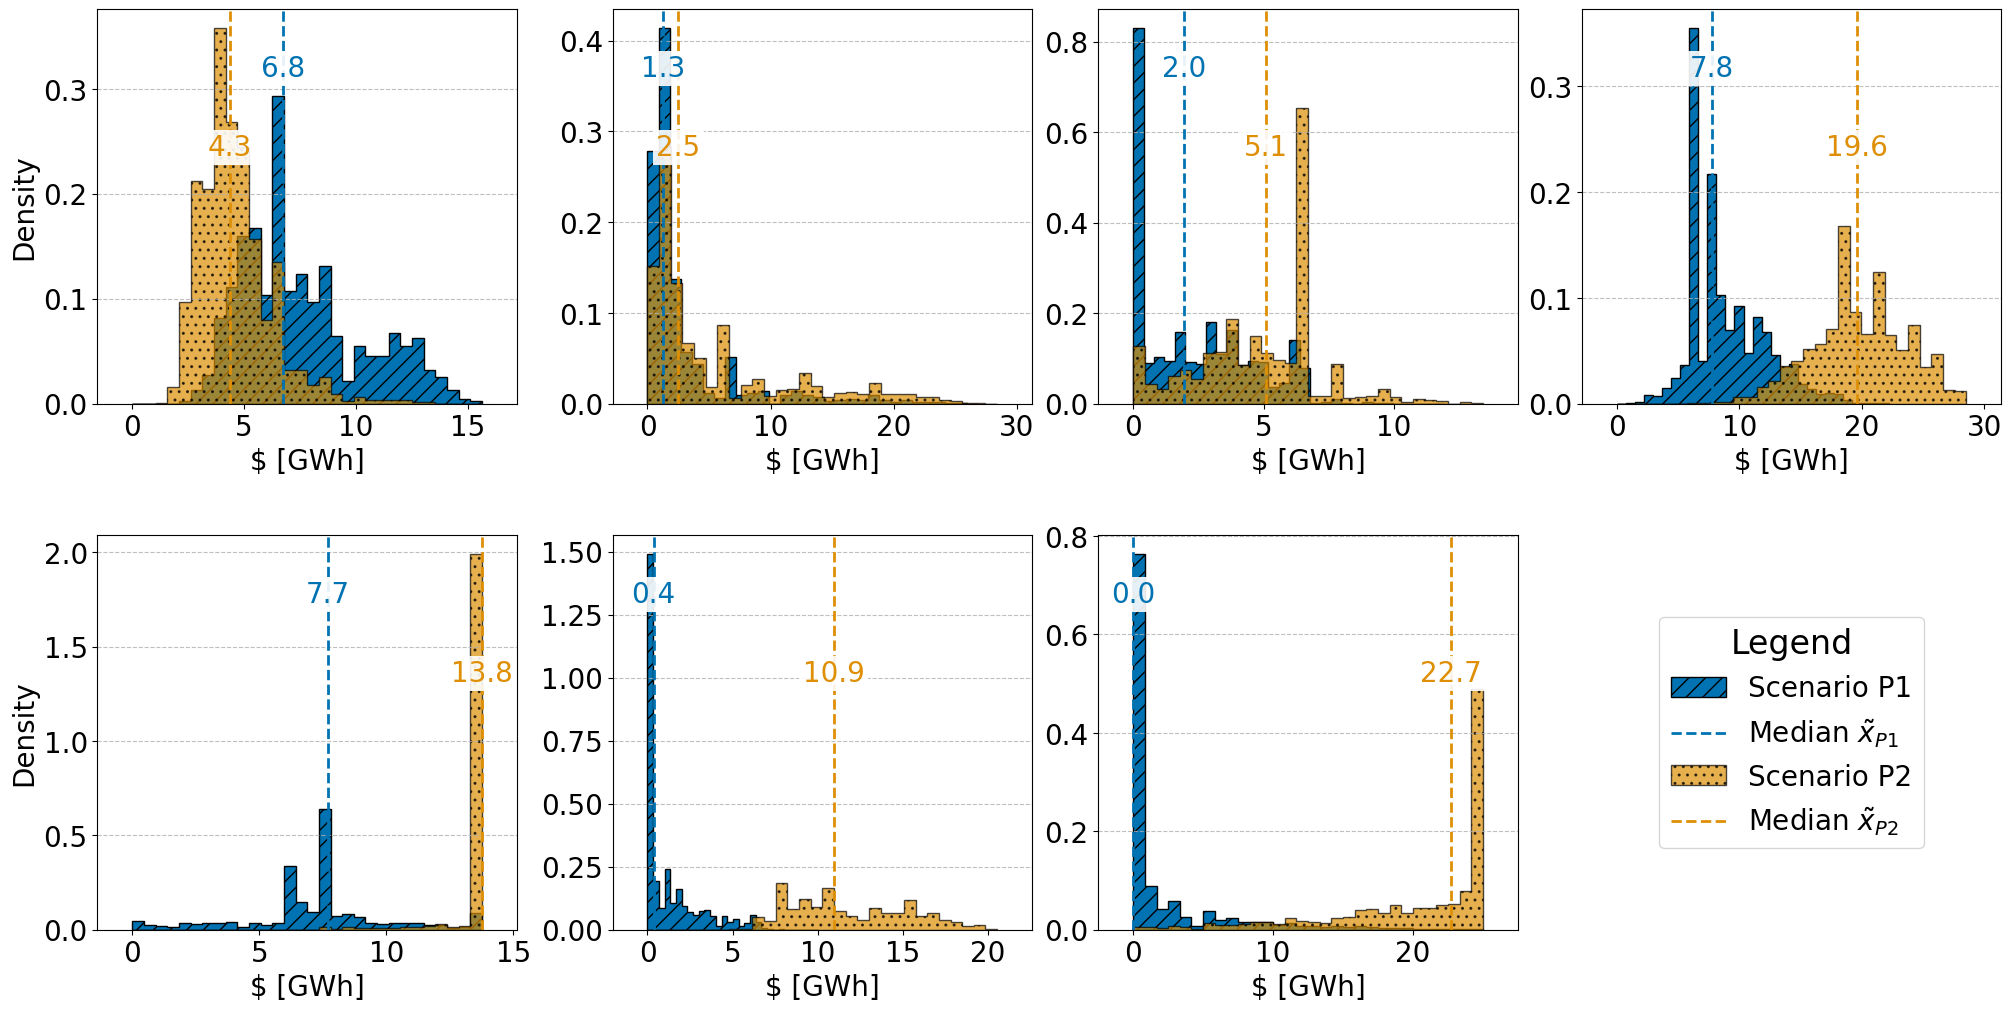

In [18]:
n_plots = len(plot_indices)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), layout="constrained")
fig.set_constrained_layout_pads(hspace=0.1) 
axes = axes.flatten()

palette = sns.color_palette("colorblind", len(scenarios))
hatches = ["//", "..", "xx"] 

for j, orig_idx in enumerate(plot_indices):
    original_name = data.columns[orig_idx]
    col_name = name_map.get(original_name, (original_name, ""))[0]
    
    title_clean = re.sub(r"\s*\[.*\]$", "", col_name)
    unit = "GWh"

    max_val = 0.0
    medians_for_annotation = []

    for k, (label, result_obj) in enumerate(scenario_results.items()):
        res_idx = result_obj["mapping"][orig_idx]
        x_cond = result_obj["data"][0][res_idx]

        max_val = max(max_val, x_cond.max())
        cond_median = np.median(x_cond)
        
        # Histogram
        axes[j].hist(
            x_cond, bins=30, range=(0, max_val if max_val > 0 else 1),
            label=f"Scenario P{k+1}",
            color=palette[k], alpha=1 - 0.3 * k,
            edgecolor="black", density=True,
            hatch=hatches[k] if k < 2 else None, histtype='stepfilled'
        )

        # Median line
        axes[j].axvline(
            cond_median,
            color=palette[k],
            linestyle="--", linewidth=2,
            label=fr"Median $\tilde{{x}}_{{{label[-2:]}}}$"
        )
        
        medians_for_annotation.append((cond_median, palette[k], f"{cond_median:.1f}"))

    # Formatting
    axes[j].set_xlabel(f"{title_clean} [{unit}]", fontsize=20)
    axes[j].grid(axis="y", linestyle="--", alpha=0.8)
    axes[j].set_xlim(-0.1 * max_val, max_val * 1.1)
    axes[j].tick_params(axis='both', which='both', labelsize=20)

    # --- Staggered Median Labels Logic ---
    ymin, ymax = axes[j].get_ylim()
    base_height = 0.85
    height_step = 0.20

    for idx, (m_val, m_col, m_text) in enumerate(medians_for_annotation):
        y_pos = ymax * (base_height - (idx * height_step))
        
        axes[j].text(
            m_val, y_pos,
            m_text,
            color=m_col,
            fontsize=20, 
            rotation=0,
            va="center", ha="center",
            bbox=dict(facecolor="white", edgecolor="none", pad=2.5, alpha=0.9)
        )

    if j % n_cols == 0:
        axes[j].set_ylabel("Density", fontsize=20)

# --- Unified Legend Logic ---
handles, labels = axes[0].get_legend_handles_labels()
if len(axes) > n_plots:
    legend_ax = axes[n_plots]
    legend_ax.set_axis_off()
    legend_ax.legend(handles, labels, loc="center", frameon=True, fontsize=20, title="Legend", title_fontsize=24)

# Clean up remaining empty axes
for k in range(n_plots + 1, len(axes)):
    fig.delaxes(axes[k])
plt.show()